In [ ]:

import pandas as pd
df = pd.read_csv("/content/archive (1).zip")
df.head()

,meanfreq,sd,median,Q25,Q75,IQR,skew,kurt,sp.ent,sfm,...,centroid,meanfun,minfun,maxfun,meandom,mindom,maxdom,dfrange,modindx,label
0,0.059781,0.064241,0.032027,0.015071,0.090193,0.075122,12.863462,274.402906,0.893369,0.491918,...,0.059781,0.084279,0.015702,0.275862,0.007812,0.007812,0.007812,0.000000,0.000000,male
1,0.066009,0.067310,0.040229,0.019414,0.092666,0.073252,22.423285,634.613855,0.892193,0.513724,...,0.066009,0.107937,0.015826,0.250000,0.009014,0.007812,0.054688,0.046875,0.052632,male
2,0.077316,0.083829,0.036718,0.008701,0.131908,0.123207,30.757155,1024.927705,0.846389,0.478905,...,0.077316,0.098706,0.015656,0.271186,0.007990,0.007812,0.015625,0.007812,0.046512,male
3,0.151228,0.072111,0.158011,0.096582,0.207955,0.111374,1.232831,4.177296,0.963322,0.727232,...,0.151228,0.088965,0.017798,0.250000,0.201497,0.007812,0.562500,0.554688,0.247119,male
4,0.135120,0.079146,0.124656,0.078720,0.206045,0.127325,1.101174,4.333713,0.971955,0.783568,...,0.135120,0.106398,0.016931,0.266667,0.712812,0.007812,5.484375,5.476562,0.208274,male


In [ ]:
print(df.shape)
print(df.columns)
print(df["label"].value_counts())


(3168, 21)
Index(['meanfreq', 'sd', 'median', 'Q25', 'Q75', 'IQR', 'skew', 'kurt',
       'sp.ent', 'sfm', 'mode', 'centroid', 'meanfun', 'minfun', 'maxfun',
       'meandom', 'mindom', 'maxdom', 'dfrange', 'modindx', 'label'],
      dtype='object')
label
male      1584
female    1584
Name: count, dtype: int64


In [ ]:
X = df.drop("label", axis=1)
y = df["label"]

In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

y = le.fit_transform(y)

print(y[:10])



[1 1 1 1 1 1 1 1 1 1]


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf.fit(X_train, y_train)

RandomForestClassifier(n_estimators=200, random_state=42)

In [ ]:
y_pred = rf.predict(X_test)

In [ ]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(
    y_test,
    y_pred
)

print("Accuracy:", accuracy)

Accuracy: 0.9842271293375394


In [ ]:
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score
)

print(
    "Precision:",
    precision_score(y_test, y_pred)
)

print(
    "Recall:",
    recall_score(y_test, y_pred)
)

print(
    "F1 Score:",
    f1_score(y_test, y_pred)
)


Precision: 0.9939577039274925
Recall: 0.9762611275964391
F1 Score: 0.9850299401197605


In [ ]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    y_test,
    y_pred
)

print(cm)


[[295   2]
 [  8 329]]


In [ ]:
import joblib

joblib.dump(rf, "gender_model.pkl")
joblib.dump(scaler, "scaler.pkl")

print("Model Saved Successfully")


Model Saved Successfully


In [ ]:
import os

print(os.path.exists("gender_model.pkl"))
print(os.path.exists("scaler.pkl"))

True
True


In [ ]:
y_pred = rf.predict(X_test)

In [ ]:
import pandas as pd

results = pd.DataFrame({
    'Actual': y_test,
    'Predicted': y_pred
})

print(results.head(20))

    Actual  Predicted
0        0          0
1        1          1
2        1          1
3        0          0
4        0          0
5        0          0
6        1          1
7        1          1
8        0          0
9        1          1
10       0          0
11       0          0
12       0          0
13       0          0
14       0          0
15       0          0
16       0          0
17       0          0
18       0          0
19       1          1


In [ ]:
results['Actual'] = results['Actual'].map({0:'Female', 1:'Male'})
results['Predicted'] = results['Predicted'].map({0:'Female', 1:'Male'})

print(results.head(20))


    Actual Predicted
0   Female    Female
1     Male      Male
2     Male      Male
3   Female    Female
4   Female    Female
5   Female    Female
6     Male      Male
7     Male      Male
8   Female    Female
9     Male      Male
10  Female    Female
11  Female    Female
12  Female    Female
13  Female    Female
14  Female    Female
15  Female    Female
16  Female    Female
17  Female    Female
18  Female    Female
19    Male      Male


In [ ]:
results['Status'] = results['Actual'] == results['Predicted']

print(results.head(20))

    Actual Predicted  Status
0   Female    Female    True
1     Male      Male    True
2     Male      Male    True
3   Female    Female    True
4   Female    Female    True
5   Female    Female    True
6     Male      Male    True
7     Male      Male    True
8   Female    Female    True
9     Male      Male    True
10  Female    Female    True
11  Female    Female    True
12  Female    Female    True
13  Female    Female    True
14  Female    Female    True
15  Female    Female    True
16  Female    Female    True
17  Female    Female    True
18  Female    Female    True
19    Male      Male    True


In [ ]:
correct = (y_test == y_pred).sum()
total = len(y_test)

print("Correct Predictions:", correct)
print("Total Predictions:", total)
print("Accuracy:", correct/total)

Correct Predictions: 624
Total Predictions: 634
Accuracy: 0.9842271293375394


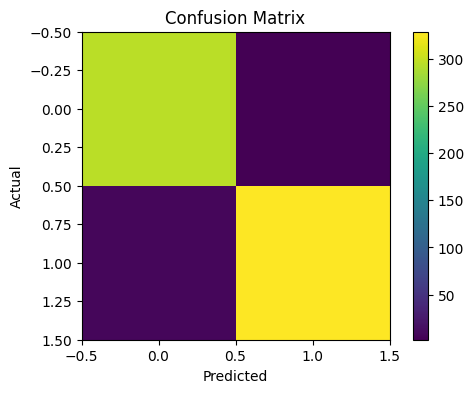

In [ ]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
plt.imshow(cm)
plt.colorbar()

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

AI -AGENTS

In [ ]:
import joblib

rf = joblib.load("gender_model.pkl")
scaler = joblib.load("scaler.pkl")

In [ ]:
import os
print(os.listdir())

['.config', 'archive.zip', 'sample_data']


In [ ]:
import joblib

joblib.dump(rf, "gender_model.pkl")

['gender_model.pkl']

In [ ]:
import joblib

rf = joblib.load("gender_model.pkl")

print("Model loaded successfully!")

Model loaded successfully!


In [ ]:
print(rf)

RandomForestClassifier(n_estimators=200, random_state=42)


In [ ]:
import gradio as gr
import joblib

# Load model
rf = joblib.load("gender_model.pkl")

feature_names = [
    "meanfreq","sd","median","Q25","Q75","IQR",
    "skew","kurt","sp.ent","sfm","mode","centroid",
    "meanfun","minfun","maxfun","meandom",
    "mindom","maxdom","dfrange","modindx"
]

def gender_agent(*features):
    prediction = rf.predict([list(features)])[0]

    if prediction == "male":
        return "👨 Predicted Gender: Male"
    else:
        return "👩 Predicted Gender: Female"

inputs = [gr.Number(label=name) for name in feature_names]

demo = gr.Interface(
    fn=gender_agent,
    inputs=inputs,
    outputs="text",
    title="Speech-Based Gender Recognition AI Agent"
)

demo.launch()

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://fd7e224612d58d4a8c.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
